# 03. Insights, Validación y Enfoque de Producto

## Qué quiero lograr

En este cuaderno quiero cerrar la distancia entre análisis y producto. Mi objetivo ya no es limpiar ni perfilar, sino decidir qué hallazgos vale la pena mostrar, qué preguntas sí puedo contestar y cómo traducir eso a un backend grounded y a una demo defendible.

## Cómo voy a filtrar los resultados

Voy a distinguir entre:

1. observaciones con evidencia suficiente,
2. interpretaciones razonables pero acotadas,
3. claims que todavía no debo prometer.

Ese filtro, para mí, es una parte central del trabajo de AI engineering.


## Preparación del entorno

Voy a trabajar directamente sobre `data/processed/` porque eso se parece mucho más a cómo operará el producto real. No quiero que dashboard o bot dependan de releer el raw a cada consulta.


In [1]:
from __future__ import annotations

import json
import os
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "data" / "processed").exists():
    ROOT = ROOT.parent

os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".matplotlib"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROCESSED_DIR = ROOT / "data" / "processed"

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.max_rows", 120)


## Helpers para traducir análisis a producto

Defino helpers pequeños para resumir cobertura, confianza y answerability. La razón es muy concreta: quiero que las reglas que uso para decidir si algo entra al dashboard o al bot sean visibles y repetibles.


In [2]:
def coverage_flag(ratio: float | int | None) -> str:
    # Resume cobertura observada en una etiqueta compacta.
    if ratio is None or pd.isna(ratio):
        return "sin evidencia"
    if ratio >= 0.95:
        return "alta"
    if ratio >= 0.80:
        return "media"
    return 'baja'


def support_status(is_supported: bool, caution: bool = False) -> str:
    # Expresa si una pregunta o insight es apto para producto.
    if not is_supported:
        return "no soportado"
    if caution:
        return "soportado con cautela"
    return "soportado"


def hourly_coverage_ratio(n_points: float | int | None) -> float | None:
    # Normaliza una hora observada contra el máximo esperado de 360 puntos.
    if n_points is None or pd.isna(n_points):
        return None
    return min(float(n_points) / 360.0, 1.0)


## 1. Cargo la capa procesada y el reporte de calidad

Primero quiero traer todas las capas que voy a cruzar para tomar decisiones. Me importa especialmente cargar también el `quality_report`, porque no quiero interpretar señales sin el contexto de cobertura.


In [3]:
canonical_df = pd.read_csv(
    PROCESSED_DIR / "availability_long_canonical.csv",
    parse_dates=["timestamp", "window_start", "window_end", "hour_bucket"],
)
hourly_df = pd.read_csv(PROCESSED_DIR / "availability_hourly.csv", parse_dates=["hour_bucket"])
daily_df = pd.read_csv(
    PROCESSED_DIR / "availability_daily.csv",
    parse_dates=["first_timestamp", "last_timestamp"],
)
anomaly_df = pd.read_csv(
    PROCESSED_DIR / "availability_hourly_anomalies.csv",
    parse_dates=["hour_bucket"],
)
step_change_df = pd.read_csv(
    PROCESSED_DIR / "availability_step_changes.csv",
    parse_dates=["timestamp"],
)
quality_report = json.loads((PROCESSED_DIR / "availability_quality_report.json").read_text())

processed_overview = pd.DataFrame(
    [
        {
            "observed_start": quality_report["observed_start"],
            "observed_end": quality_report["observed_end"],
            "canonical_timestamps": quality_report["canonical_timestamp_count"],
            "missing_ratio_full_range": quality_report["missing_ratio_full_range"],
            "duplicate_window_groups": quality_report["duplicate_window_groups"],
            "incomplete_window_records": quality_report["incomplete_window_records"],
        }
    ]
)

display(processed_overview)


,observed_start,observed_end,canonical_timestamps,missing_ratio_full_range,duplicate_window_groups,incomplete_window_records
0,2026-02-01T06:11:20-05:00,2026-02-11T15:00:00-05:00,67141,0.250433,4,27


Esta tabla me ayuda a anclar toda la discusión posterior. Si sé desde el inicio que la cobertura no es perfecta, entonces ya sé que cualquier lectura fuerte necesita un lenguaje prudente y trazable.


## 2. Quiero identificar qué historias diarias valen la pena contar

En esta sección no quiero solo mirar la tabla diaria; quiero convertirla en candidatos reales de narrativa. Voy a revisar días fuertes, días débiles, cambios respecto al día anterior y siempre voy a acompañarlo de cobertura.


,date,n_points,min_value,max_value,mean_value,median_value,std_value,first_value,last_value,first_timestamp,last_timestamp,delta_close_open,pct_change_close_open,expected_points_in_observed_span,coverage_ratio_in_observed_span,coverage_flag,prev_mean_value,delta_vs_prev_day,pct_vs_prev_day,story_ready
0,2026-02-01,6412,37,5280107,3022545.521,3370193.5,1783000.111,37,980304,2026-02-01 06:11:20-05:00,2026-02-01 23:59:50-05:00,980267,2649370.270,6412,1.000,alta,NaN,NaN,NaN,sí
1,2026-02-02,6399,28,4554582,2620566.558,3051516.0,1476897.401,979359,843143,2026-02-02 00:00:00-05:00,2026-02-02 23:59:50-05:00,-136216,-13.909,8640,0.741,baja,3022545.521,-401978.962,-13.299,con cautela
2,2026-02-03,6413,0,5708166,3379388.151,3942590.0,1933380.803,842111,1031859,2026-02-03 00:00:00-05:00,2026-02-03 23:59:50-05:00,189748,22.532,8640,0.742,baja,2620566.558,758821.592,28.956,con cautela
3,2026-02-04,6451,0,5917626,3524981.773,4083087.0,2016760.941,1030636,1136168,2026-02-04 00:00:00-05:00,2026-02-04 23:59:50-05:00,105532,10.240,8640,0.747,baja,3379388.151,145593.622,4.308,con cautela
4,2026-02-05,6413,0,6107574,3663628.492,4079481.0,2070888.954,1134935,1397752,2026-02-05 00:00:00-05:00,2026-02-05 23:59:50-05:00,262817,23.157,8640,0.742,baja,3524981.773,138646.719,3.933,con cautela
5,2026-02-06,6429,0,6198472,3722633.139,4181438.0,2099722.880,1396354,1505657,2026-02-06 00:00:00-05:00,2026-02-06 23:59:50-05:00,109303,7.828,8640,0.744,baja,3663628.492,59004.647,1.611,con cautela
6,2026-02-07,6450,155,5738300,3480623.344,4059191.0,1950815.978,1504845,1504124,2026-02-07 00:00:00-05:00,2026-02-07 23:59:50-05:00,-721,-0.048,8640,0.747,baja,3722633.139,-242009.795,-6.501,con cautela
7,2026-02-08,6093,101,4969210,2741441.158,3167102.0,1615538.896,1501845,1016005,2026-02-08 00:00:00-05:00,2026-02-08 23:59:50-05:00,-485840,-32.350,8640,0.705,baja,3480623.344,-739182.186,-21.237,con cautela
8,2026-02-09,6432,22,5122526,3067438.832,3547481.5,1728046.480,1016317,978329,2026-02-09 00:00:00-05:00,2026-02-09 23:59:50-05:00,-37988,-3.738,8640,0.744,baja,2741441.158,325997.674,11.891,con cautela
9,2026-02-10,6436,0,5767000,3209285.928,3260584.5,1915493.864,977300,1075282,2026-02-10 00:00:00-05:00,2026-02-10 23:59:50-05:00,97982,10.026,8640,0.745,baja,3067438.832,141847.096,4.624,con cautela


,date,mean_value,coverage_ratio_in_observed_span,coverage_flag,story_ready
5,2026-02-06,3722633.139,0.744,baja,con cautela
4,2026-02-05,3663628.492,0.742,baja,con cautela
3,2026-02-04,3524981.773,0.747,baja,con cautela


,date,mean_value,coverage_ratio_in_observed_span,coverage_flag,story_ready
10,2026-02-11,2462669.379,0.595,baja,con cautela
1,2026-02-02,2620566.558,0.741,baja,con cautela
7,2026-02-08,2741441.158,0.705,baja,con cautela


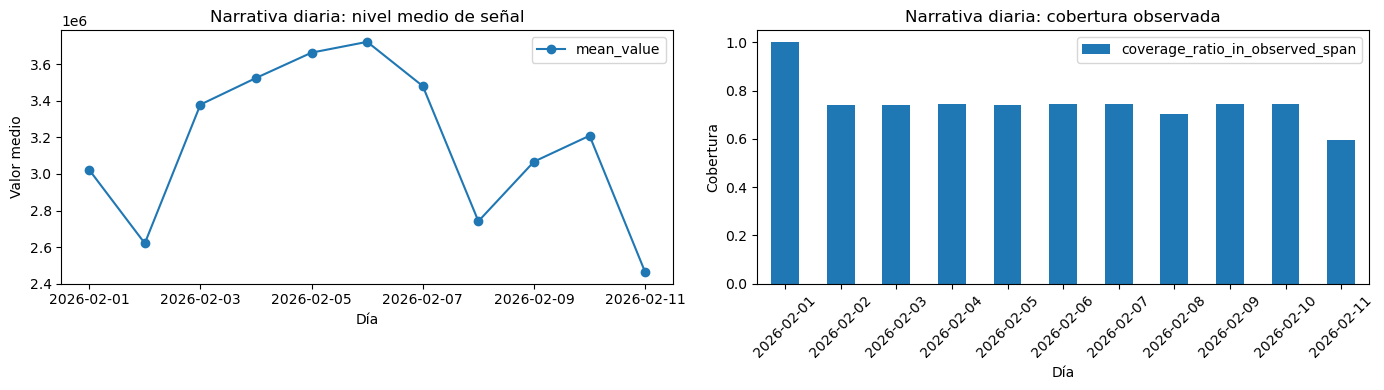

In [4]:
daily_story = daily_df.copy()
daily_story["coverage_flag"] = daily_story["coverage_ratio_in_observed_span"].map(coverage_flag)
daily_story["prev_mean_value"] = daily_story["mean_value"].shift(1)
daily_story["delta_vs_prev_day"] = daily_story["mean_value"] - daily_story["prev_mean_value"]
daily_story["pct_vs_prev_day"] = (
    daily_story["delta_vs_prev_day"]
    / daily_story["prev_mean_value"].replace(0, pd.NA)
    * 100
)
daily_story["story_ready"] = np.where(
    daily_story["coverage_ratio_in_observed_span"] >= 0.80,
    "sí",
    "con cautela",
)

best_days = daily_story.sort_values("mean_value", ascending=False)[
    ["date", "mean_value", "coverage_ratio_in_observed_span", "coverage_flag", "story_ready"]
].head(3)

weak_days = daily_story.sort_values("mean_value", ascending=True)[
    ["date", "mean_value", "coverage_ratio_in_observed_span", "coverage_flag", "story_ready"]
].head(3)

display(daily_story.round(3))
display(best_days.round(3))
display(weak_days.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
daily_story.plot(
    x="date",
    y="mean_value",
    kind="line",
    marker="o",
    ax=axes[0],
    title="Narrativa diaria: nivel medio de señal",
)
daily_story.plot(
    x="date",
    y="coverage_ratio_in_observed_span",
    kind="bar",
    ax=axes[1],
    title="Narrativa diaria: cobertura observada",
)
axes[0].set_xlabel("Día")
axes[0].set_ylabel("Valor medio")
axes[1].set_xlabel("Día")
axes[1].set_ylabel("Cobertura")
plt.xticks(rotation=45)
plt.tight_layout()


Aquí me interesa evitar una mala costumbre: contar el “mejor” o “peor” día sin decir con qué cobertura llegó. Para demo y producto, me parece mucho más serio mostrar el valor junto con la confianza o, al menos, con una advertencia contextual.


## 3. Quiero ver si el patrón intradiario justifica una visual principal

El dashboard y el bot ganan mucho valor si existe una forma diaria clara. Por eso acá construyo un perfil intradiario más explícito: quiero detectar horas pico, horas valle y estabilidad promedio por hora.


,hour,mean_of_hourly_means,median_of_hourly_means,std_of_hourly_means,avg_n_points,hourly_coverage_ratio,coverage_flag,rank_high,rank_low
0,0,703551.189,599188.468,208179.480,35.700,0.099,baja,16.0,4.0
1,6,13241.857,13022.521,1755.692,291.818,0.811,media,19.0,1.0
2,7,37830.637,38142.281,2452.433,356.455,0.990,alta,18.0,2.0
3,8,371885.142,380861.427,36434.393,355.273,0.987,alta,17.0,3.0
4,9,1234259.912,1264807.022,142243.519,360.000,1.000,alta,15.0,5.0
5,10,2154595.881,2174176.606,254896.276,360.000,1.000,alta,13.0,7.0
6,11,2883112.941,2907967.969,341010.860,360.000,1.000,alta,11.0,9.0
7,12,3726390.189,3934228.589,398630.156,360.000,1.000,alta,10.0,10.0
8,13,4510962.885,4723546.147,427493.137,360.000,1.000,alta,7.0,13.0
9,14,5158839.693,5382707.861,448866.217,360.000,1.000,alta,3.0,17.0


,hour,mean_of_hourly_means,median_of_hourly_means,std_of_hourly_means,avg_n_points,hourly_coverage_ratio,coverage_flag,rank_high,rank_low
12,17,5247763.445,5486271.261,663536.402,360.000,1.000,alta,1.0,19.0
10,15,5238696.932,5566834.747,732374.712,327.364,0.909,media,2.0,18.0
9,14,5158839.693,5382707.861,448866.217,360.000,1.000,alta,3.0,17.0
11,16,5146310.459,5369630.828,904518.168,360.000,1.000,alta,4.0,16.0
13,18,4983317.411,5203277.590,681892.284,360.000,1.000,alta,5.0,15.0


,hour,mean_of_hourly_means,median_of_hourly_means,std_of_hourly_means,avg_n_points,hourly_coverage_ratio,coverage_flag,rank_high,rank_low
1,6,13241.857,13022.521,1755.692,291.818,0.811,media,19.0,1.0
2,7,37830.637,38142.281,2452.433,356.455,0.990,alta,18.0,2.0
3,8,371885.142,380861.427,36434.393,355.273,0.987,alta,17.0,3.0
0,0,703551.189,599188.468,208179.480,35.700,0.099,baja,16.0,4.0
4,9,1234259.912,1264807.022,142243.519,360.000,1.000,alta,15.0,5.0


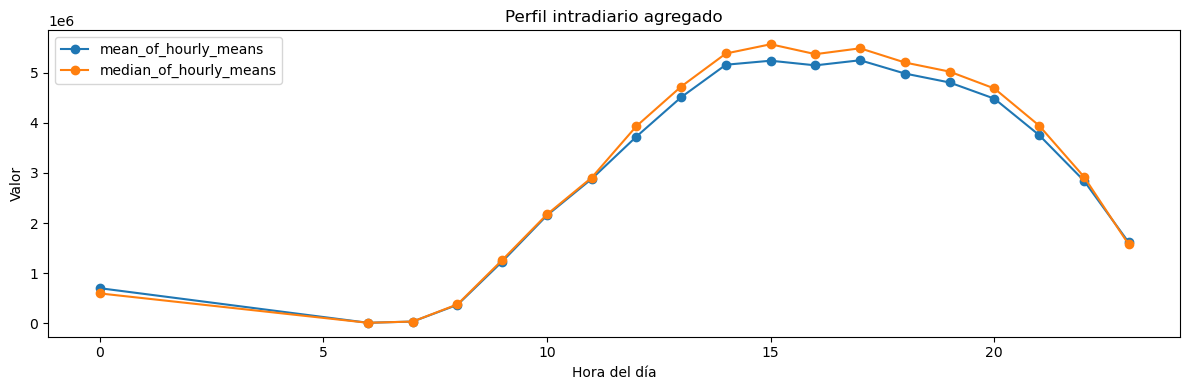

In [5]:
hour_profile = (
    hourly_df.groupby("hour")
    .agg(
        mean_of_hourly_means=("mean_value", "mean"),
        median_of_hourly_means=("mean_value", "median"),
        std_of_hourly_means=("mean_value", "std"),
        avg_n_points=("n_points", "mean"),
    )
    .reset_index()
)
hour_profile["hourly_coverage_ratio"] = hour_profile["avg_n_points"].map(hourly_coverage_ratio)
hour_profile["coverage_flag"] = hour_profile["hourly_coverage_ratio"].map(coverage_flag)
hour_profile["rank_high"] = hour_profile["mean_of_hourly_means"].rank(ascending=False, method="dense")
hour_profile["rank_low"] = hour_profile["mean_of_hourly_means"].rank(ascending=True, method="dense")

peak_hours = hour_profile.sort_values("mean_of_hourly_means", ascending=False).head(5)
low_hours = hour_profile.sort_values("mean_of_hourly_means", ascending=True).head(5)

display(hour_profile.round(3))
display(peak_hours.round(3))
display(low_hours.round(3))

fig, ax = plt.subplots(figsize=(12, 4))
hour_profile.plot(
    x="hour",
    y=["mean_of_hourly_means", "median_of_hourly_means"],
    marker="o",
    ax=ax,
    title="Perfil intradiario agregado",
)
ax.set_xlabel("Hora del día")
ax.set_ylabel("Valor")
plt.tight_layout()


Este bloque es especialmente valioso para producto. Si la señal tiene un perfil intradiario estable, entonces ya no estoy construyendo una app que solo lista números: estoy construyendo una herramienta que entiende qué es normal a cada hora y qué se desvía de ese baseline.


## 4. Quiero revisar anomalías y saltos con un filtro de confianza

No toda desviación merece convertirse en highlight. Acá voy a añadir una lectura más prudente para decidir qué anomalías valen como insight y cuáles deberían quedar solo como contexto exploratorio o técnico.


In [6]:
reviewed_anomalies = anomaly_df.copy()
reviewed_anomalies["hourly_coverage_ratio"] = reviewed_anomalies["n_points"].map(hourly_coverage_ratio)
reviewed_anomalies["coverage_flag"] = reviewed_anomalies["hourly_coverage_ratio"].map(coverage_flag)
reviewed_anomalies["story_support"] = np.where(
    (reviewed_anomalies["hourly_coverage_ratio"] >= 0.95)
    & (reviewed_anomalies["zscore_vs_hour_baseline"].abs() >= 1.5),
    "fuerte",
    "moderado",
)
reviewed_anomalies["demo_candidate"] = np.where(
    reviewed_anomalies["story_support"] == "fuerte",
    "sí",
    "con cautela",
)

reviewed_step_changes = step_change_df.copy()
reviewed_step_changes["technical_relevance"] = np.select(
    [
        (~reviewed_step_changes["is_gap_or_reset"]) & (reviewed_step_changes["delta_10s"].abs() >= 100000),
        ~reviewed_step_changes["is_gap_or_reset"],
    ],
    ["alta", "media"],
    default="baja",
)

display(reviewed_anomalies.round(3))
display(reviewed_step_changes.round(3))


,hour_bucket,date,hour,mean_value,baseline_mean,baseline_median,baseline_std,zscore_vs_hour_baseline,delta_vs_hour_median,n_points,anomaly_direction,hourly_coverage_ratio,coverage_flag,story_support,demo_candidate
0,2026-02-10 16:00:00-05:00,2026-02-10,16,3337992.989,5146310.459,5369630.828,904518.168,-1.999,-2031637.839,360,low,1.000,alta,fuerte,sí
1,2026-02-10 15:00:00-05:00,2026-02-10,15,3686896.392,5199510.025,5363055.850,759737.505,-1.991,-1676159.458,360,low,1.000,alta,fuerte,sí
2,2026-02-02 14:00:00-05:00,2026-02-02,14,4273888.183,5158839.693,5382707.861,448866.217,-1.972,-1108819.678,360,low,1.000,alta,fuerte,sí
3,2026-02-02 19:00:00-05:00,2026-02-02,19,3788506.917,4915295.709,5093007.081,573341.886,-1.965,-1304500.164,360,low,1.000,alta,fuerte,sí
4,2026-02-08 19:00:00-05:00,2026-02-08,19,3809549.000,4915295.709,5093007.081,573341.886,-1.929,-1283458.081,3,low,0.008,baja,moderado,con cautela
5,2026-02-02 13:00:00-05:00,2026-02-02,13,3700439.575,4510962.885,4723546.147,427493.137,-1.896,-1023106.572,360,low,1.000,alta,fuerte,sí
6,2026-02-02 21:00:00-05:00,2026-02-02,21,2972146.797,3757024.357,3945847.694,415250.436,-1.890,-973700.897,360,low,1.000,alta,fuerte,sí
7,2026-02-02 17:00:00-05:00,2026-02-02,17,4026046.533,5247763.445,5486271.261,663536.402,-1.841,-1460224.728,360,low,1.000,alta,fuerte,sí
8,2026-02-02 20:00:00-05:00,2026-02-02,20,3473206.486,4482142.386,4685403.554,558141.899,-1.808,-1212197.068,360,low,1.000,alta,fuerte,sí
9,2026-02-02 12:00:00-05:00,2026-02-02,12,3022421.664,3726390.189,3934228.589,398630.156,-1.766,-911806.925,360,low,1.000,alta,fuerte,sí


,timestamp,value,delta_10s,pct_change_10s,is_gap_or_reset,timestamp_occurrences,has_conflicting_values,technical_relevance
0,2026-02-05 06:11:20-05:00,0,-1134935.0,-100.000,True,1,False,baja
1,2026-02-02 23:08:50-05:00,1479469,-399030.0,-21.242,True,1,False,baja
2,2026-02-09 20:40:50-05:00,3712403,195324.0,5.554,False,1,False,alta
3,2026-02-06 08:04:00-05:00,237035,187523.0,378.743,True,1,False,baja
4,2026-02-09 20:45:50-05:00,4366257,-186481.0,-4.096,False,1,False,alta
5,2026-02-09 20:46:00-05:00,4197397,-168860.0,-3.867,False,1,False,alta
6,2026-02-09 20:41:00-05:00,3876953,164550.0,4.432,False,1,False,alta
7,2026-02-09 20:41:10-05:00,4025112,148159.0,3.822,False,1,False,alta
8,2026-02-10 16:39:00-05:00,3919500,145161.0,3.846,False,1,False,alta
9,2026-02-09 20:46:10-05:00,4052578,-144819.0,-3.450,False,1,False,alta


Aquí me interesa transmitir una postura madura: una anomalía puede ser útil sin que eso implique que ya entiendo la causa. Lo que sí puedo hacer bien es detectar el desvío, cuantificarlo y mostrar con qué confianza apareció.


## 5. Quiero convertir el análisis en KPIs reales de dashboard

En lugar de una lista genérica de KPIs, aquí quiero proponer indicadores concretos y calcular un snapshot con los datos procesados. La idea es que el dashboard principal salga de aquí, no de intuiciones sueltas.


In [7]:
dashboard_kpi_snapshot = pd.DataFrame(
    [
        {
            "metric": "Nivel medio de señal del período",
            "value": daily_story["mean_value"].mean(),
            "why_it_matters": "Resume el comportamiento agregado del período sin inventar granularidad por tienda.",
            "caution": "Debe mostrarse junto con cobertura del período.",
        },
        {
            "metric": "Cobertura efectiva del histórico observado",
            "value": 1 - quality_report["missing_ratio_full_range"],
            "why_it_matters": "Hace visible la salud del dato y evita sobreconfianza.",
            "caution": "No representa disponibilidad de negocio; representa continuidad observada del dataset.",
        },
        {
            "metric": "Hora típica de mayor señal",
            "value": int(hour_profile.sort_values("mean_of_hourly_means", ascending=False).iloc[0]["hour"]),
            "why_it_matters": "Ayuda a contar el patrón intradiario y a contextualizar comparaciones.",
            "caution": "Habla de patrón agregado, no de causalidad.",
        },
        {
            "metric": "Horas anómalas fuertes detectadas",
            "value": int((reviewed_anomalies["story_support"] == "fuerte").sum()),
            "why_it_matters": "Señala desvíos que merecen explicación o inspección adicional.",
            "caution": "Debe acompañarse de baseline y cobertura.",
        },
    ]
)

dashboard_sections = pd.DataFrame(
    [
        {
            "section": "Resumen ejecutivo",
            "what_to_show": "Nivel medio, cobertura y rango observado del período.",
            "source": "availability_daily.csv + quality_report",
        },
        {
            "section": "Patrón intradiario",
            "what_to_show": "Perfil horario típico y comparación contra baseline.",
            "source": "availability_hourly.csv",
        },
        {
            "section": "Anomalías con contexto",
            "what_to_show": "Horas desviadas con coverage flag y magnitud del z-score.",
            "source": "availability_hourly_anomalies.csv",
        },
        {
            "section": "Calidad del dato",
            "what_to_show": "Cobertura, duplicados tratados e incompletitud relevante.",
            "source": "quality_report + window metadata",
        },
    ]
)

display(dashboard_kpi_snapshot.round(3))
display(dashboard_sections)


,metric,value,why_it_matters,caution
0,Nivel medio de señal del período,3172291.116,Resume el comportamiento agregado del período ...,Debe mostrarse junto con cobertura del período.
1,Cobertura efectiva del histórico observado,0.750,Hace visible la salud del dato y evita sobreco...,No representa disponibilidad de negocio; repre...
2,Hora típica de mayor señal,17.000,Ayuda a contar el patrón intradiario y a conte...,"Habla de patrón agregado, no de causalidad."
3,Horas anómalas fuertes detectadas,17.000,Señala desvíos que merecen explicación o inspe...,Debe acompañarse de baseline y cobertura.


,section,what_to_show,source
0,Resumen ejecutivo,"Nivel medio, cobertura y rango observado del p...",availability_daily.csv + quality_report
1,Patrón intradiario,Perfil horario típico y comparación contra bas...,availability_hourly.csv
2,Anomalías con contexto,Horas desviadas con coverage flag y magnitud d...,availability_hourly_anomalies.csv
3,Calidad del dato,"Cobertura, duplicados tratados e incompletitud...",quality_report + window metadata


Esta celda es importante porque obliga a pasar de “insights interesantes” a “producto defendible”. Si un KPI no puedo explicarlo con fuente, utilidad y cautela, entonces no debería entrar al dashboard todavía.


## 6. Quiero dejar explícito qué preguntas sí puede responder el bot

Acá quiero traducir la analítica a capacidades concretas del chatbot. Mi criterio es duro: el bot solo debería responder aquello que pueda resolverse con consultas determinísticas sobre `processed/` y luego formatearse con LLM.


In [8]:
bot_capability_matrix = pd.DataFrame(
    [
        {
            "intent": "trend_summary",
            "example_question": "¿Cómo evolucionó la métrica entre el 8 y el 10 de febrero?",
            "support_status": support_status(True),
            "deterministic_source": "availability_daily.csv",
            "why": "Se resuelve con comparación temporal directa y cobertura por día.",
        },
        {
            "intent": "intraday_pattern",
            "example_question": "¿Qué horas suelen ser más altas o más bajas?",
            "support_status": support_status(True),
            "deterministic_source": "availability_hourly.csv",
            "why": "Existe un baseline por hora que permite responder con evidencia agregada.",
        },
        {
            "intent": "anomaly_review",
            "example_question": "¿Qué horas se desviaron más de su baseline?",
            "support_status": support_status(True, caution=True),
            "deterministic_source": "availability_hourly_anomalies.csv",
            "why": "Es respondible, pero siempre debería incluir cobertura/confianza.",
        },
        {
            "intent": "data_quality_status",
            "example_question": "¿Qué tan completo es el histórico y qué limitaciones tiene?",
            "support_status": support_status(True),
            "deterministic_source": "availability_quality_report.json",
            "why": "La calidad del dato está materializada de forma explícita.",
        },
        {
            "intent": "store_ranking",
            "example_question": "¿Qué tiendas estuvieron peor?",
            "support_status": support_status(False),
            "deterministic_source": "no aplica",
            "why": "El dataset no expone entidades de tienda ni granularidad individual.",
        },
        {
            "intent": "root_cause",
            "example_question": "¿Por qué cayó la métrica ese día?",
            "support_status": support_status(False),
            "deterministic_source": "no aplica",
            "why": "Puedo describir el cambio, pero no inferir causalidad con este dataset solo.",
        },
    ]
)

display(bot_capability_matrix)


,intent,example_question,support_status,deterministic_source,why
0,trend_summary,¿Cómo evolucionó la métrica entre el 8 y el 10...,soportado,availability_daily.csv,Se resuelve con comparación temporal directa y...
1,intraday_pattern,¿Qué horas suelen ser más altas o más bajas?,soportado,availability_hourly.csv,Existe un baseline por hora que permite respon...
2,anomaly_review,¿Qué horas se desviaron más de su baseline?,soportado con cautela,availability_hourly_anomalies.csv,"Es respondible, pero siempre debería incluir c..."
3,data_quality_status,¿Qué tan completo es el histórico y qué limita...,soportado,availability_quality_report.json,La calidad del dato está materializada de form...
4,store_ranking,¿Qué tiendas estuvieron peor?,no soportado,no aplica,El dataset no expone entidades de tienda ni gr...
5,root_cause,¿Por qué cayó la métrica ese día?,no soportado,no aplica,"Puedo describir el cambio, pero no inferir cau..."


Para mí esta matriz es de mucho valor porque demuestra autocontrol técnico. Un bot bueno no es el que inventa más; es el que responde bien dentro de un dominio claramente acotado y sabe cuándo no debe afirmar algo.


## 7. Quiero aterrizar qué consultas determinísticas debería exponer el backend

El bot grounded necesita una capa intermedia clara. En esta celda quiero convertir lo anterior en familias de consulta que luego se puedan mapear a endpoints o servicios backend.


In [9]:
backend_query_contract = pd.DataFrame(
    [
        {
            "query_family": "overview_period",
            "response_shape": "nivel medio, cobertura, rango observado, advertencias",
            "primary_source": "availability_daily.csv + quality_report",
            "why": "Es la base del dashboard principal y de preguntas ejecutivas.",
        },
        {
            "query_family": "compare_periods",
            "response_shape": "diferencia absoluta/relativa entre dos rangos comparables",
            "primary_source": "availability_daily.csv o availability_hourly.csv",
            "why": "Permite comparación temporal grounded sin usar el LLM para calcular.",
        },
        {
            "query_family": "intraday_profile",
            "response_shape": "baseline por hora, hora pico, hora valle, horas con mejor cobertura",
            "primary_source": "availability_hourly.csv",
            "why": "Sostiene gráficos y respuestas semánticas sobre el comportamiento típico.",
        },
        {
            "query_family": "anomaly_context",
            "response_shape": "desviación, baseline, cobertura, nivel de confianza",
            "primary_source": "availability_hourly_anomalies.csv + availability_step_changes.csv",
            "why": "Permite responder sobre anomalías sin perder grounding.",
        },
        {
            "query_family": "quality_status",
            "response_shape": "cobertura, gaps, duplicados tratados, limitaciones del rango",
            "primary_source": "availability_quality_report.json + window metadata",
            "why": "Reduce alucinaciones y obliga a que el bot contextualice sus respuestas.",
        },
    ]
)

display(backend_query_contract)


,query_family,response_shape,primary_source,why
0,overview_period,"nivel medio, cobertura, rango observado, adver...",availability_daily.csv + quality_report,Es la base del dashboard principal y de pregun...
1,compare_periods,diferencia absoluta/relativa entre dos rangos ...,availability_daily.csv o availability_hourly.csv,Permite comparación temporal grounded sin usar...
2,intraday_profile,"baseline por hora, hora pico, hora valle, hora...",availability_hourly.csv,Sostiene gráficos y respuestas semánticas sobr...
3,anomaly_context,"desviación, baseline, cobertura, nivel de conf...",availability_hourly_anomalies.csv + availabili...,Permite responder sobre anomalías sin perder g...
4,quality_status,"cobertura, gaps, duplicados tratados, limitaci...",availability_quality_report.json + window meta...,Reduce alucinaciones y obliga a que el bot con...


## 8. Qué concluyo para producto y demo

Después de todo el recorrido, lo que considero defendible es esto:

- el producto correcto es analytics-first sobre una señal agregada,
- el dashboard debe priorizar tendencia, patrón intradiario, anomalías con contexto y calidad del dato,
- el bot debe trabajar como intérprete semántico de consultas determinísticas y no como generador de verdad numérica,
- la ausencia de granularidad por tienda no es una debilidad si la explico bien: es una restricción del dataset que estoy respetando con criterio.

Eso, bien contado, demuestra más madurez que prometer capacidades no soportadas por los datos.
